In [607]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [608]:
df = pd.read_excel("plik.xlsx")
print(df.head())

   Ankieta Płeć  \
0      1.0    K   
1      2.0    K   
2      3.0    K   
3      4.0    K   
4      5.0    K   

  Czy na którymś etapie edukacji miałeś/aś matematykę na poziomie rozszerzonym?  \
0                                                Nie                              
1                                                Nie                              
2                                                Nie                              
3                                                Nie                              
4                                                Tak                              

  Czy na którymś etapie edukacji miałeś/aś wprowadzone pojęcie statystyki oraz jej składowych, na którym?  \
0                                        Tak, studia                                                        
1                                                Nie                                                        
2                                        Tak, studia       

In [609]:
df = df.replace(',', '.', regex=True)

In [610]:
df = df.loc[:, ~df.columns.str.endswith(".1")]

In [611]:
print(len(df.columns))  # powinno być 21

21


In [612]:
df.columns = [
    "ankieta", "Płeć", "Matematyka rozszerzona", "Etap edukacji",
    "statystyka_studia", "testy_diag", "artykuly_naukowe",
    "srednia_kolano", "srednia_sklon", "mediana_rehab",
    "mediana_sport", "dominanta_wizyty", "rozstep_biodro",
    "q1", "odchylenie", "wsp_zmiennosci",
    "czulosc_test", "swoistosc_test",
    "istotnosc_stat", "Rok studiów", "wynik"
]


In [613]:
df["Płeć"] = df["Płeć"].map({
    "M": "Mężczyzna",
    "K": "Kobieta"
})

In [614]:
def extract_number(x):
    if isinstance(x, str):
        match = re.search(r"[-+]?\d*\.?\d+", x)
        return float(match.group()) if match else None
    return x

cols_num = [
    "srednia_kolano", "srednia_sklon", "mediana_rehab",
    "mediana_sport", "dominanta_wizyty", "rozstep_biodro"
]

for col in cols_num:
    df[col] = df[col].apply(extract_number)

In [615]:
print(df.dtypes)
print(df.head())

ankieta                   float64
Płeć                       object
Matematyka rozszerzona     object
Etap edukacji              object
statystyka_studia          object
testy_diag                 object
artykuly_naukowe           object
srednia_kolano            float64
srednia_sklon             float64
mediana_rehab             float64
mediana_sport             float64
dominanta_wizyty          float64
rozstep_biodro            float64
q1                         object
odchylenie                 object
wsp_zmiennosci             object
czulosc_test               object
swoistosc_test             object
istotnosc_stat             object
Rok studiów                object
wynik                       int64
dtype: object
   ankieta     Płeć Matematyka rozszerzona                Etap edukacji  \
0      1.0  Kobieta                    Nie                  Tak. studia   
1      2.0  Kobieta                    Nie                          Nie   
2      3.0  Kobieta                    Nie     

Średni wynik: 7.504


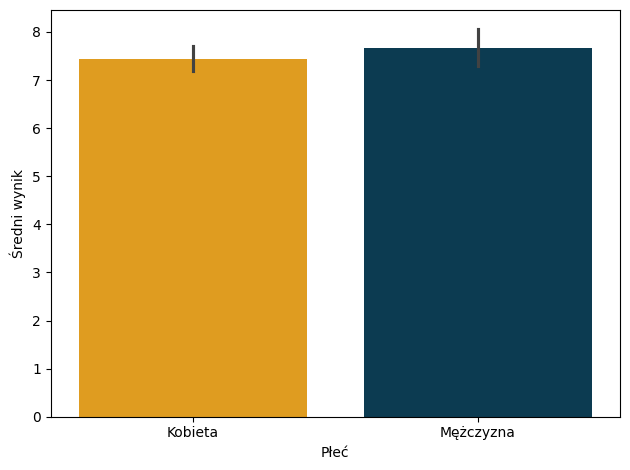

In [616]:
print("Średni wynik:", df["wynik"].mean())

sns.barplot(data=df, x="Płeć", y="wynik", errorbar=('ci'), hue='Płeć', palette=["#ffa600", "#003f5c"])

plt.xlabel("Płeć")
plt.ylabel("Średni wynik")

plt.tight_layout()
plt.savefig("ready/sredni_wynik_plec.svg", dpi=300)

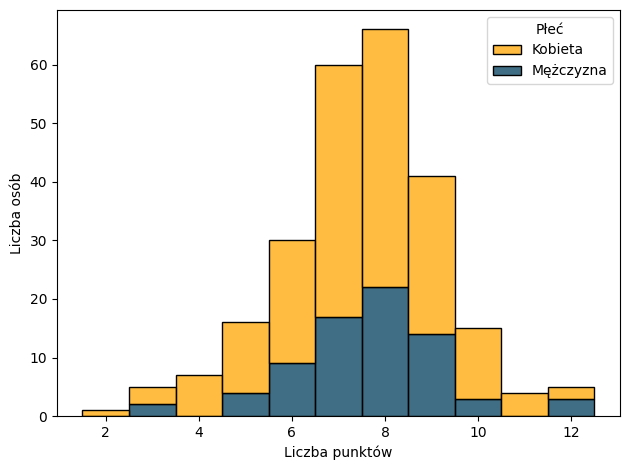

In [617]:
ax = sns.histplot(data=df, x="wynik", discrete=True, hue='Płeć', palette=["#ffa600", "#003f5c"], multiple="stack")

plt.xlabel("Liczba punktów")
plt.ylabel("Liczba osób")

plt.tight_layout()
plt.savefig("ready/wynik_plec.svg", dpi=300)

In [618]:
srednie = df.groupby("Płeć")["wynik"].mean()
srednie

Płeć
Kobieta      7.437500
Mężczyzna    7.662162
Name: wynik, dtype: float64

In [619]:
counts = df.groupby(["Płeć", "wynik"]).size()
print(counts)

Płeć       wynik
Kobieta    2         1
           3         3
           4         7
           5        12
           6        21
           7        43
           8        44
           9        27
           10       12
           11        4
           12        2
Mężczyzna  3         2
           5         4
           6         9
           7        17
           8        22
           9        14
           10        3
           12        3
dtype: int64


In [620]:
df["Płeć"].value_counts()

Płeć
Kobieta      176
Mężczyzna     74
Name: count, dtype: int64

In [621]:
df["Rok studiów"] = df["Rok studiów"].map({
    "Nie": "I rok",
    "X": "V rok",
})

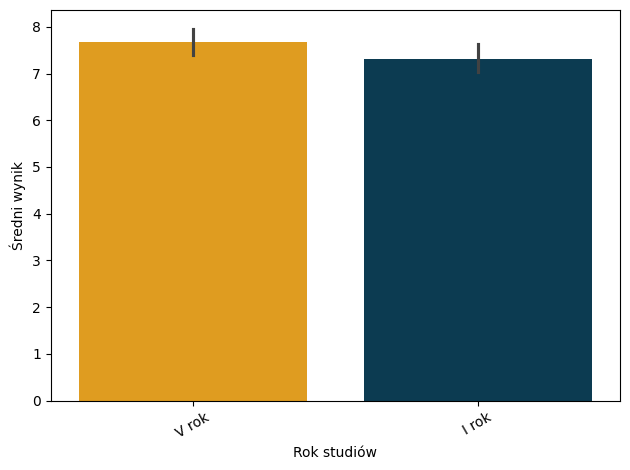

In [622]:
sns.barplot(data=df, x="Rok studiów", y="wynik", hue="Rok studiów", palette=["#ffa600", "#003f5c"])
plt.xticks(rotation=30)

plt.xlabel("Rok studiów")
plt.ylabel("Średni wynik")

plt.tight_layout()
plt.savefig("ready/sredni_wynik_rok.svg", dpi=300)

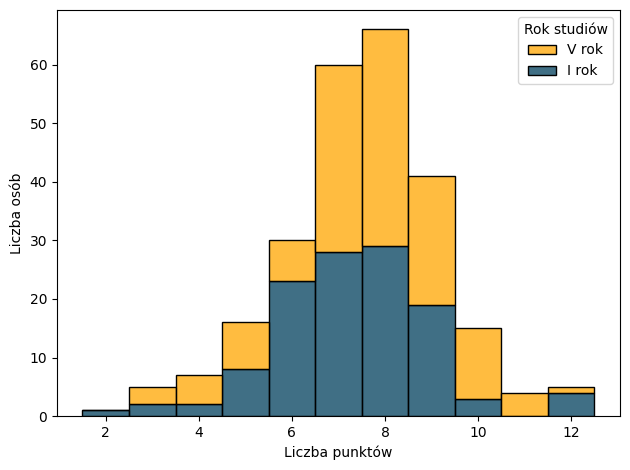

In [623]:
ax = sns.histplot(data=df, x="wynik", discrete=True, hue='Rok studiów', palette=["#ffa600", "#003f5c"], multiple="stack")

plt.xlabel("Liczba punktów")
plt.ylabel("Liczba osób")

plt.tight_layout()
plt.savefig("ready/wynik_rok.svg", dpi=300)

In [624]:
srednie = df.groupby("Rok studiów")["wynik"].mean()
srednie

Rok studiów
I rok    7.319328
V rok    7.671756
Name: wynik, dtype: float64

In [625]:
counts = df.groupby(["Rok studiów", "wynik"]).size()
print(counts)

Rok studiów  wynik
I rok        2         1
             3         2
             4         2
             5         8
             6        23
             7        28
             8        29
             9        19
             10        3
             12        4
V rok        3         3
             4         5
             5         8
             6         7
             7        32
             8        37
             9        22
             10       12
             11        4
             12        1
dtype: int64


In [626]:
df["Rok studiów"].value_counts()

Rok studiów
V rok    131
I rok    119
Name: count, dtype: int64

In [627]:
df["Etap edukacji"].unique()

array([' Tak. studia', 'Nie', 'Tak. studia',
       'Tak. szkoła ponadpodstawowa', 'X', 'Tak. szkoła podstawowa',
       'Tak. szkoła policealna'], dtype=object)

In [628]:
df["Etap edukacji"] = df["Etap edukacji"].map({
    "Nie": "Nigdy",
    "Tak. szkoła ponadpodstawowa": "Szkoła ponadpodstawowa",
    " Tak. studia": "Studia",
    "Tak. studia": "Studia",
    "Tak. szkoła podstawowa": "Szkoła podstawowa",
    "Tak. szkoła policealna": "Szkoła policealna",
    "X": "Nigdy"
})

C:\Users\Admin\AppData\Local\Temp\ipykernel_13036\1788670587.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


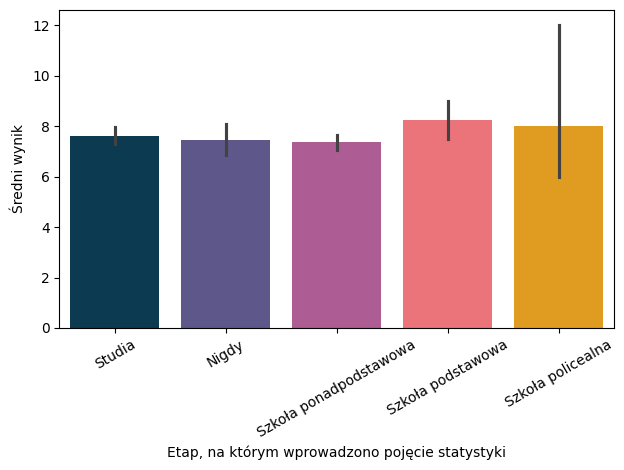

In [629]:
sns.barplot(data=df, x="Etap edukacji", y="wynik", errorbar=('ci'), hue='Etap edukacji', palette=["#003f5c", "#575092", "#bb4e99", "#ff5f68", "#ffa600"])
plt.legend().remove() 
plt.ylabel("Średni wynik")
plt.xlabel("Etap, na którym wprowadzono pojęcie statystyki")
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("ready/sredni_wynik_statystyka_edukacja.svg", dpi=300)

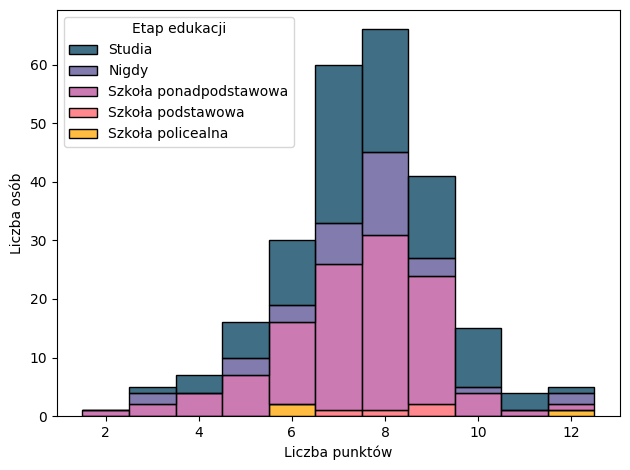

In [630]:
ax = sns.histplot(data=df, x="wynik", discrete=True, hue='Etap edukacji', palette=["#003f5c", "#575092", "#bb4e99", "#ff5f68", "#ffa600"], multiple="stack")

plt.xlabel("Liczba punktów")
plt.ylabel("Liczba osób")

plt.tight_layout()
plt.savefig("ready/wynik_sta.svg", dpi=300)

In [631]:
counts = df.groupby(["Etap edukacji", "wynik"]).size()
print(counts)

Etap edukacji           wynik
Nigdy                   3         2
                        5         3
                        6         3
                        7         7
                        8        14
                        9         3
                        10        1
                        12        2
Studia                  3         1
                        4         3
                        5         6
                        6        11
                        7        27
                        8        21
                        9        14
                        10       10
                        11        3
                        12        1
Szkoła podstawowa       7         1
                        8         1
                        9         2
Szkoła policealna       6         2
                        12        1
Szkoła ponadpodstawowa  2         1
                        3         2
                        4         4
                        5         

In [632]:
srednie = df.groupby("Etap edukacji")["wynik"].mean()
srednie

Etap edukacji
Nigdy                     7.457143
Studia                    7.618557
Szkoła podstawowa         8.250000
Szkoła policealna         8.000000
Szkoła ponadpodstawowa    7.378378
Name: wynik, dtype: float64

In [633]:
df["Etap edukacji"].value_counts()

Etap edukacji
Szkoła ponadpodstawowa    111
Studia                     97
Nigdy                      35
Szkoła podstawowa           4
Szkoła policealna           3
Name: count, dtype: int64

In [634]:
df["Matematyka rozszerzona"] = df["Matematyka rozszerzona"].map({
    "Nie": "Nie",
    "Tak": "Tak"
})

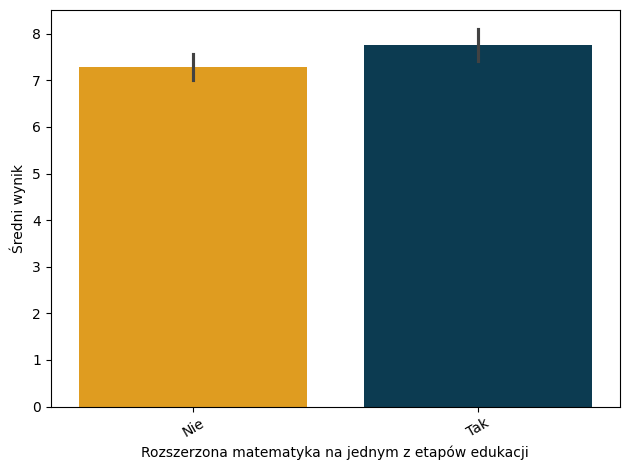

In [635]:
sns.barplot(data=df, x="Matematyka rozszerzona", y="wynik", errorbar=('ci'), hue='Matematyka rozszerzona', palette=["#ffa600", "#003f5c"])
plt.legend().remove() 
plt.ylabel("Średni wynik")
plt.xlabel("Rozszerzona matematyka na jednym z etapów edukacji")
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("ready/sredni_wynik_statystyka_studia.svg", dpi=300)

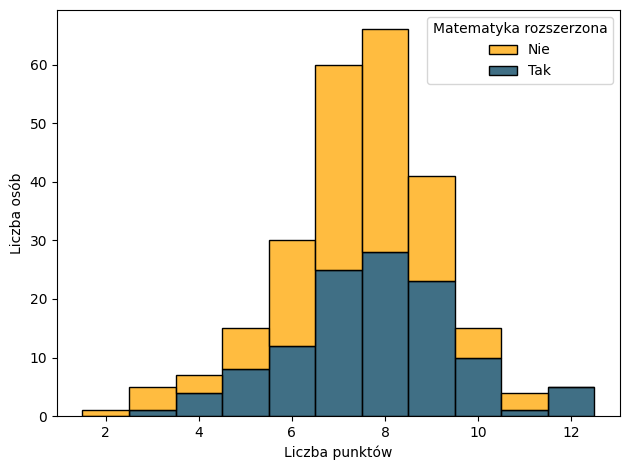

In [636]:
ax = sns.histplot(data=df, x="wynik", discrete=True, hue='Matematyka rozszerzona', palette=["#ffa600", "#003f5c"], multiple="stack")

plt.xlabel("Liczba punktów")
plt.ylabel("Liczba osób")

plt.tight_layout()
plt.savefig("ready/wynik_mat.svg", dpi=300)

In [637]:
srednie = df.groupby("Matematyka rozszerzona")["wynik"].mean()
srednie

Matematyka rozszerzona
Nie    7.295455
Tak    7.760684
Name: wynik, dtype: float64

In [638]:
counts = df.groupby(["Matematyka rozszerzona", "wynik"]).size()
print(counts)

Matematyka rozszerzona  wynik
Nie                     2         1
                        3         4
                        4         3
                        5         7
                        6        18
                        7        35
                        8        38
                        9        18
                        10        5
                        11        3
Tak                     3         1
                        4         4
                        5         8
                        6        12
                        7        25
                        8        28
                        9        23
                        10       10
                        11        1
                        12        5
dtype: int64


In [639]:
df["Matematyka rozszerzona"].value_counts()

Matematyka rozszerzona
Nie    132
Tak    117
Name: count, dtype: int64

In [640]:
df["czulosc_test"] = df["czulosc_test"].map({
    "aa": "A",
    "a": "A",
    "A. Test rzadko daje wyniki fałszywie dodatnie": "A",
    "B. Test dobrze wykrywa osoby zdrowe": "B",
    "C. Test rzadko pomija pacjentów z niestabilnością": "C",
    "D. Test ma wysoką dokładność ogólną": "D",
    "X": "Brak"
})

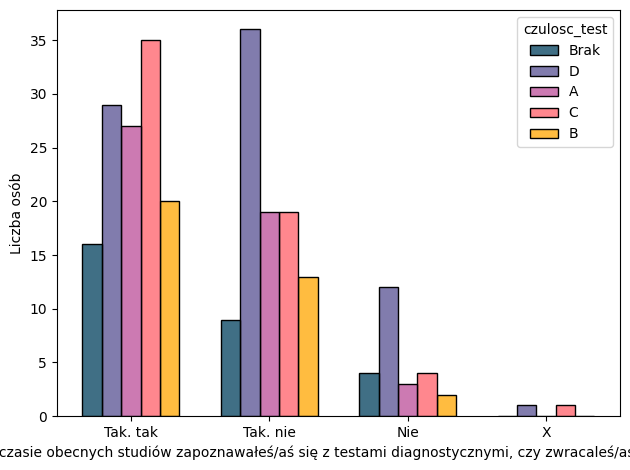

In [652]:
order = ["A", "B", "C", "D", "Brak"]

ax = sns.histplot(data=df, x="testy_diag", discrete=True, hue='czulosc_test', palette=["#003f5c", "#575092", "#bb4e99", "#ff5f68", "#ffa600"], multiple="dodge", shrink=0.7)

plt.xlabel('Odpowiedzi na pytanie "Czy w czasie obecnych studiów zapoznawałeś/aś się z testami diagnostycznymi, czy zwracaleś/aś uwagę na jego czułość i swoistość?" ')
plt.ylabel("Liczba osób")

plt.tight_layout()
plt.savefig("ready/wynik_czu.svg", dpi=300)

In [642]:
df["swoistosc_test"].unique()

array(['X', 'B. Test rzadko daje wyniki fałszywie dodatnie',
       'C. Test rzadko daje wyniki fałszywie ujemne',
       'D. Test jest najlepszy jako badanie przesiewowe',
       'A. Test często wykrywa chorobę u osób zdrowych'], dtype=object)

In [643]:
df["swoistosc_test"] = df["swoistosc_test"].map({
    "A. Test często wykrywa chorobę u osób zdrowych": "A",
    "B. Test rzadko daje wyniki fałszywie dodatnie": "B",
    "C. Test rzadko daje wyniki fałszywie ujemne": "C",
    "D. Test jest najlepszy jako badanie przesiewowe": "D",
    "X": "Brak"
})

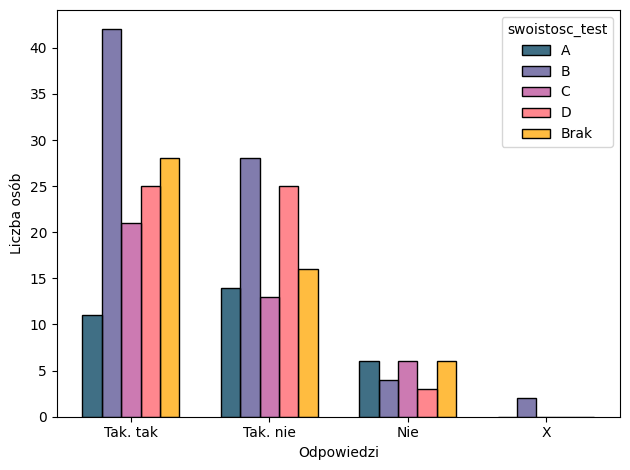

In [651]:
order = ["A", "B", "C", "D", "Brak"]

ax = sns.histplot(data=df, x="testy_diag", discrete=True, hue='swoistosc_test', hue_order=order, palette=["#003f5c", "#575092", "#bb4e99", "#ff5f68", "#ffa600"], multiple="dodge", shrink=0.7)

plt.xlabel("Odpowiedzi")
plt.ylabel("Liczba osób")

plt.tight_layout()
plt.savefig("ready/wynik_swo.svg", dpi=300)

In [645]:
data = df
data = data[data["artykuly_naukowe"] != "X"]

In [647]:

df_clean = df[["artykuly_naukowe", 'istotnosc_stat']].dropna()

df_clean["Odpowiedzi"] = df_clean['istotnosc_stat'].str.findall(r"[A-DX]")
df_exploded = df_clean.explode("Odpowiedzi")
df_exploded

,artykuly_naukowe,istotnosc_stat,Odpowiedzi
0,Tak. tak,X,X
1,Tak. tak,A,A
2,Tak. nie,X,X
3,Tak. nie,X,X
4,Tak. nie,X,X
...,...,...,...
245,Nie,X,X
246,Tak. tak,X,X
247,Tak. tak,X,X
248,Tak. tak,A,A


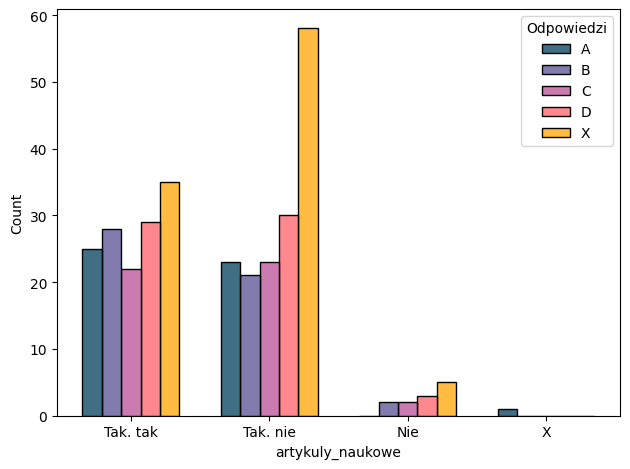

In [648]:
order = ["A", "B", "C", "D", "X"]

ax = sns.histplot(data=df_exploded, x="artykuly_naukowe", discrete=True, hue='Odpowiedzi', palette=["#003f5c", "#575092", "#bb4e99", "#ff5f68", "#ffa600"], multiple="dodge", shrink=0.7, hue_order=order)


plt.tight_layout()
plt.savefig("ready/wynik_art.svg", dpi=300)


E - statystyka_studia
statystyka_studia
Tak    184
Nie     63
X        3
Name: count, dtype: int64

F - testy_diag
testy_diag
Tak. tak    127
Tak. nie     96
Nie          25
X             2
Name: count, dtype: int64


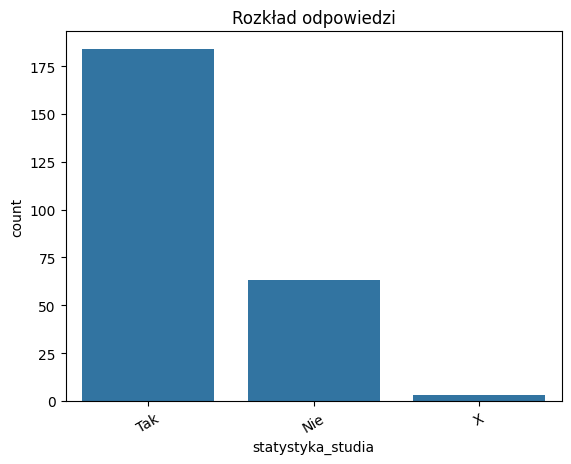

In [649]:
print("E - statystyka_studia")
print(df["statystyka_studia"].value_counts())

print("\nF - testy_diag")
print(df["testy_diag"].value_counts())

sns.countplot(data=df, x="statystyka_studia")
plt.title("Rozkład odpowiedzi")
plt.xticks(rotation=30)
plt.show()

In [650]:
cols = df.columns[8:20]  # dostosuj zakres!

for col in cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())


=== srednia_sklon ===
srednia_sklon
8.39     221
11.50     10
4.01       8
3.28       1
Name: count, dtype: int64

=== mediana_rehab ===
mediana_rehab
8.0     246
7.0       2
6.0       1
10.0      1
Name: count, dtype: int64

=== mediana_sport ===
mediana_sport
12.0    228
13.0      8
11.0      8
14.0      2
Name: count, dtype: int64

=== dominanta_wizyty ===
dominanta_wizyty
3.0    216
5.0     25
4.0      5
Name: count, dtype: int64

=== rozstep_biodro ===
rozstep_biodro
40.0     221
30.0       5
220.0      3
20.0       2
Name: count, dtype: int64

=== q1 ===
q1
A. 25% wyników    145
C. 75% wyników     60
X                  36
B. 50% wyników      8
s                   1
Name: count, dtype: int64

=== odchylenie ===
odchylenie
B. Wyniki są skupione blisko średniej    202
A. Wyniki są bardzo zróżnicowane          25
X                                         12
C. Średnia jest wysoka                     6
D. Mediana równa się zero                  4
x                                    